In [36]:
import numpy as np 
import matplotlib.pyplot as plt

In [37]:
def after_tax_income_single(gross_income):

    # 2025 standard deduction (single filer)
    standard_deduction = 15_750
    taxable_income = max(0, gross_income - standard_deduction)

    # Federal income tax brackets (single filer, 2025)
    brackets = [
        (11925, 0.10),
        (48475, 0.12),
        (103350, 0.22),
        (197300, 0.24), 
        (250525, 0.32), 
(626350, 0.35)  
    ]

    federal_tax = 0
    prev_limit = 0

    for limit, rate in brackets:
        if taxable_income > limit:
            federal_tax += (limit - prev_limit) * rate
            prev_limit = limit
        else:
            federal_tax += (taxable_income - prev_limit) * rate
            break

    # Payroll taxes
    social_security = min(0.062 * gross_income, 184500)
    medicare = 0.0145 * gross_income

    total_tax = federal_tax + social_security + medicare
    net_income = gross_income - total_tax

    return round(net_income, 2)


def after_tax_income_married(gross_income):

    # 2025 standard deduction (single filer)
    standard_deduction = 31_500
    taxable_income = max(0, gross_income - standard_deduction)

    # Federal income tax brackets (single filer, 2025)
    brackets = [
        (23850, 0.10),
        (96950 , 0.12),
        (206700, 0.22),
        (394600 , 0.24), 
        (501050 , 0.32), 
(751600 , 0.35)  
    ]

    federal_tax = 0
    prev_limit = 0

    for limit, rate in brackets:
        if taxable_income > limit:
            federal_tax += (limit - prev_limit) * rate
            prev_limit = limit
        else:
            federal_tax += (taxable_income - prev_limit) * rate
            break

    # Payroll taxes
    social_security = min(0.062 * gross_income, 184500)
    medicare = 0.0145 * gross_income

    total_tax = federal_tax + social_security + medicare
    net_income = gross_income - total_tax

    return round(net_income, 2)




In [38]:
## single calculations

gross_values_ages = [48514, 102494, 128285, 141121, 121571, 75460, 56028]
gross_values_states = [115770, 97104, 93814, 120365]

# Compute after-tax income for each gross value (used as after_tax_single below)
after_tax_age_single = np.array([after_tax_income_single(g) for g in gross_values_ages])
after_tax_age_married = np.array([after_tax_income_married(g) for g in gross_values_ages])

after_tax_state_single = np.array([after_tax_income_single(g) for g in gross_values_states])
after_tax_state_married = np.array([after_tax_income_married(g) for g in gross_values_states])

print(f"{'Gross':>12} {'Tax':>12} {'Net':>12}")
print("-" * 38)
for i, g in enumerate(gross_values_ages):
    net = after_tax_age_single[i]
    tax = g - net
    print(f"${g:>10,} ${tax:>10,.2f} ${net:>10,.2f}")



       Gross          Tax          Net
--------------------------------------
$    48,514 $  7,404.50 $ 41,109.50
$   102,494 $ 21,838.47 $ 80,655.53
$   128,285 $ 29,669.20 $ 98,615.80
$   141,121 $ 33,731.80 $107,389.20
$   121,571 $ 27,544.22 $ 94,026.78
$    75,460 $ 13,822.89 $ 61,637.11
$    56,028 $  8,881.00 $ 47,147.00


In [39]:
## married calculations

for g in gross_values:
    net = after_tax_income_married(g)
    tax = g - net
    print(f"${g:>10,} ${tax:>10,.2f} ${net:>10,.2f}")

$    48,514 $  5,412.72 $ 43,101.28
$   102,494 $ 15,883.07 $ 86,610.93
$   128,285 $ 20,951.00 $107,334.00
$   141,121 $ 24,740.38 $116,380.62
$   121,571 $ 19,631.70 $101,939.30
$    75,460 $ 10,570.89 $ 64,889.11
$    56,028 $  6,752.50 $ 49,275.50
$   115,770 $ 18,491.80 $ 97,278.20
$    97,104 $ 14,823.94 $ 82,280.06
$    93,814 $ 14,177.45 $ 79,636.55
$   120,365 $ 19,394.72 $100,970.28


In [40]:
after_tax_single = np.array([39089.66,	76376.54,	93247.69,	101475.56,	88944.01,	58507.06, 	44807.81])
age = np.array([(25+18)/2, (34+25)/2, (44+35)/2, (54+45)/2, (64+55)/2, (74+65)/2, (78+75)/2]) #av

after_tax_married = np.array([39328.16,	80406.94,	98510.39,	106994.98,	94072.43,	59834.06, 	45046.31])
age = np.array([(25+18)/2, (34+25)/2, (44+35)/2, (54+45)/2, (64+55)/2, (74+65)/2, (78+75)/2]) #averaging age brackets, maybe make better lattr

necessary_expenses_age = np.array([43_131, 70_871, 87_985, 92_356, 79_920, 62_396, 53_608])
necessary_expenses_states = np.array([79_267, 69_498, 67_463, 86_936])

disposable_income_single = after_tax_single - necessary_expenses_age
disposable_income_married = after_tax_married - necessary_expenses_age

# plt.title("Age vs disposable income")
# plt.scatter(age, disposable_income)
# plt.show()

proportion_single = disposable_income_single/after_tax_single
proportion_married = disposable_income_married/after_tax_married


In [43]:
print(disposable_income_single)
print(disposable_income_married)

[-4041.34  5505.54  5262.69  9119.56  9024.01 -3888.94 -8800.19]
[-3802.84  9535.94 10525.39 14638.98 14152.43 -2561.94 -8561.69]


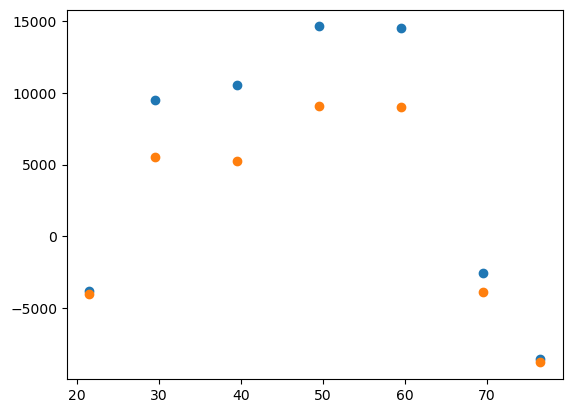

In [ ]:
plt.scatter(age, disposable_income_married) 
plt.scatter(age, disposable_income_single)

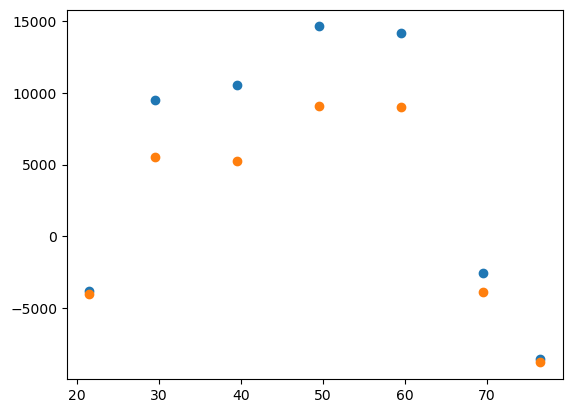

In [41]:
plt.scatter(age, disposable_income_married) 
plt.scatter(age, disposable_income_single)

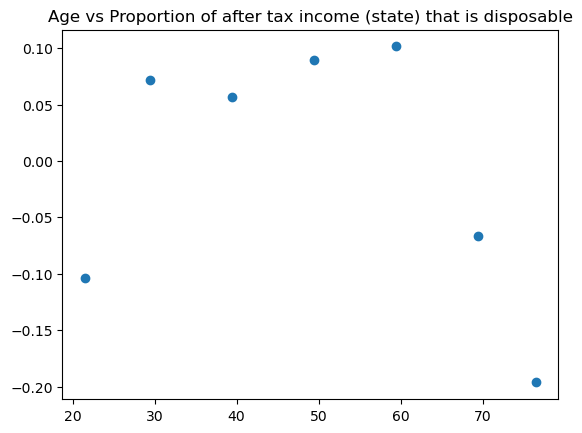

In [10]:
plt.title("Age vs Proportion of after tax income (state) that is disposable")
plt.scatter(age, disposable_income_single/after_tax_single)
#plt.show()